In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
df=pd.read_csv('diabetes.csv')
df 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:

x=df.drop('Outcome',axis=1)
y=df['Outcome']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
RF=RandomForestClassifier(criterion='entropy',random_state=42,n_estimators=51)
RF.fit(x_train,y_train)
y_pred=RF.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7662337662337663
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [16]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
df=pd.read_csv('titanic.csv')
df 

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [17]:
df=df.drop(['cabin','ticket','name'],axis=1)
df.embarked=df.embarked.fillna(df.embarked.mode()[0])
df=df.fillna(df.mean(numeric_only=True))
y=df['survived']
x=df.drop('survived',axis=1)
x=pd.get_dummies(x)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [20]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
ac_knn=0
for i in range(27,45):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    ac=accuracy_score(y_test,y_pred)
    if ac>ac_knn:
        ac_knn=ac
        neighbor=i
print(ac,">",neighbor)

0.6526717557251909 > 39


In [21]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
ac_dt=0
for i in range(1,50):
    DT=DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=i)
    DT.fit(x_train,y_train)
    y_pred=DT.predict(x_test)
    ac=accuracy_score(y_pred,y_test)
    if ac>ac_dt:
        ac_dt=ac
        depth=i
print(ac_dt,">",i)

0.7786259541984732 > 49


In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
ac_rf =0
for i in range(30,100):
    rf = RandomForestClassifier(n_estimators=i,criterion='entropy',random_state=42)
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    ac=accuracy_score(y_pred,y_test)
    if ac>ac_rf:
        ac_rf=ac
        n=i
print(ac_rf,">",n)

0.7938931297709924 > 45


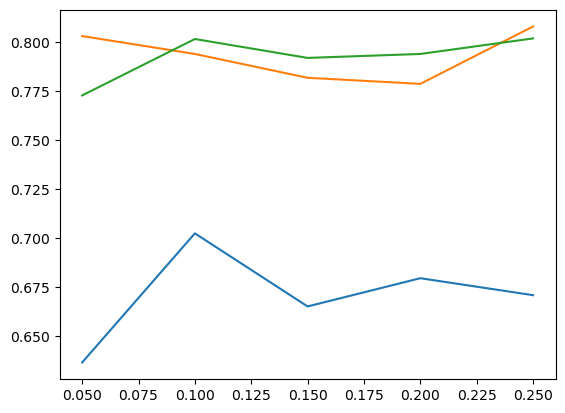

In [25]:
import matplotlib.pyplot as plt
ac_knn=[]
ac_dt=[]
ac_rf=[]
test=[0.05,0.1,0.15,0.2,0.25]
for i in test:
    x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=i,random_state=42)
    knn= KNeighborsClassifier(n_neighbors=39)
    knn.fit(x_train, y_train)
    y_pred= knn.predict(x_test)
    ac_knn.append(accuracy_score(y_test, y_pred))

    dt= DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=3)
    dt.fit(x_train, y_train)
    y_pred= dt.predict(x_test)
    ac_dt.append(accuracy_score(y_test, y_pred))

    rf= RandomForestClassifier(criterion='entropy', random_state=42, n_estimators=45)
    rf.fit(x_train, y_train)
    y_pred= rf.predict(x_test)
    ac_rf.append(accuracy_score(y_pred, y_test))

plt.plot(test,ac_knn)
plt.plot(test, ac_dt)
plt.plot(test, ac_rf)

In [26]:
from sklearn.datasets import load_iris
x=load_iris()

In [27]:
x

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  